Chapter 27
# 一元概率密度估计
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [1]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris

提取标签，这个数据集的标签为 0、1、2，分应'setosa'、'versicolor'、
'virginica'。

## 导入数据

In [3]:
# 从Scikit-Learn库加载鸢尾花数据
iris = load_iris()
y = iris.target #提取标签，这个数据集的标签为 0、1、2，分应'setosa'、'versicolor'、'virginica'。
X_df = pd.DataFrame(iris.data) # 将数组转为数据帧
X1_df = X_df.iloc[:,0]  # 取第一列

In [5]:
print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


In [6]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [7]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

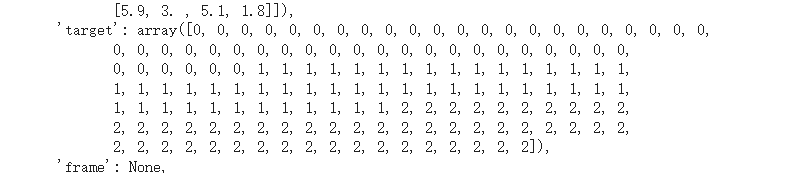

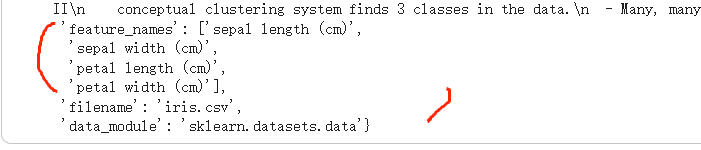

## 可视化函数

中 fill_between() 是 Matplotlib 库中的一个函数，用于在两条曲线之间填充颜色。


In [15]:
# 自定义可视化函数

# x1：x,  pdf:y,  color:颜色
def visualize(x1,pdf,color):
    fig, ax = plt.subplots(figsize = (8,3))

    #填充颜色
    ax.fill_between(x1, pdf,
                    facecolor = color,alpha = 0.2)
    # 进行绘图
    ax.plot(x1, pdf,color = color)

    ax.set_ylim([0,1.4]) # 范围
    ax.set_xlim([4,8])
    ax.set_ylabel('PDF') # 标签
    ax.set_xlabel('Sepal length, $x_1$')


导入非参数核密度估计 sm.nonparametric.KDEUnivariate() 函数，用来创建和操作单变
量数据的核密度估计对象。这个函数的输入为样本的单一变量数据。


调用 fit() 方法计算核密度估计，其中 bw 调节核函数带宽 (band width)。


In [16]:
# 不考虑标签
# X1_df: 第一列数据
KDE = sm.nonparametric.KDEUnivariate(X1_df)
KDE.fit(bw=0.1)

In [17]:
KDE

##利用 evaluate() 计算给定数组核密度估计值，以便后续可视化

In [18]:
# 生成一系列的点； 4/100
x1 = np.linspace(4,8,101)
f_x1 = KDE.evaluate(x1) #计算给定数组的核密度估计值

In [19]:
x1

array([4.  , 4.04, 4.08, 4.12, 4.16, 4.2 , 4.24, 4.28, 4.32, 4.36, 4.4 ,
       4.44, 4.48, 4.52, 4.56, 4.6 , 4.64, 4.68, 4.72, 4.76, 4.8 , 4.84,
       4.88, 4.92, 4.96, 5.  , 5.04, 5.08, 5.12, 5.16, 5.2 , 5.24, 5.28,
       5.32, 5.36, 5.4 , 5.44, 5.48, 5.52, 5.56, 5.6 , 5.64, 5.68, 5.72,
       5.76, 5.8 , 5.84, 5.88, 5.92, 5.96, 6.  , 6.04, 6.08, 6.12, 6.16,
       6.2 , 6.24, 6.28, 6.32, 6.36, 6.4 , 6.44, 6.48, 6.52, 6.56, 6.6 ,
       6.64, 6.68, 6.72, 6.76, 6.8 , 6.84, 6.88, 6.92, 6.96, 7.  , 7.04,
       7.08, 7.12, 7.16, 7.2 , 7.24, 7.28, 7.32, 7.36, 7.4 , 7.44, 7.48,
       7.52, 7.56, 7.6 , 7.64, 7.68, 7.72, 7.76, 7.8 , 7.84, 7.88, 7.92,
       7.96, 8.  ])

In [20]:
f_x1

array([3.22323342e-04, 1.02860423e-03, 2.84586324e-03, 6.86695633e-03,
       1.45495613e-02, 2.72609198e-02, 4.54692184e-02, 6.79154921e-02,
       9.14222091e-02, 1.11995392e-01, 1.27084932e-01, 1.37448849e-01,
       1.46602693e-01, 1.57807381e-01, 1.71448176e-01, 1.85732245e-01,
       1.99999038e-01, 2.16799427e-01, 2.40364802e-01, 2.73360806e-01,
       3.15440602e-01, 3.64330120e-01, 4.17020687e-01, 4.69145143e-01,
       5.13652370e-01, 5.41303211e-01, 5.43708916e-01, 5.17141128e-01,
       4.64893964e-01, 3.97250634e-01, 3.29228862e-01, 2.76644988e-01,
       2.51300312e-01, 2.56794131e-01, 2.87163202e-01, 3.29797275e-01,
       3.71422802e-01, 4.03633943e-01, 4.24934698e-01, 4.38817960e-01,
       4.49612346e-01, 4.58675869e-01, 4.63155278e-01, 4.58006495e-01,
       4.39934649e-01, 4.10742186e-01, 3.77872614e-01, 3.51344322e-01,
       3.38474332e-01, 3.39823695e-01, 3.49492663e-01, 3.59679032e-01,
       3.66134905e-01, 3.70743552e-01, 3.79572552e-01, 3.97593044e-01,
      

用自定义函数 visualize() 绘制概率密度函数曲线，'#00448A'为一个十六进制颜色值
RGB 颜色值

##绘制图像

 x1; x,  f_x1：核密度估计值

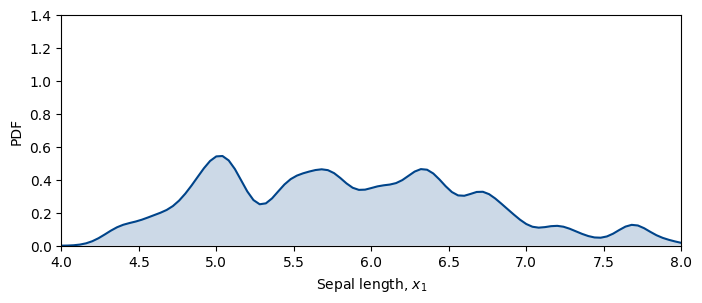

In [21]:
# x1; x,  f_x1：核密度估计值
visualize(x1,f_x1,'#00448A')


##修改核函数带宽 bw，观察 KDE 曲线变化

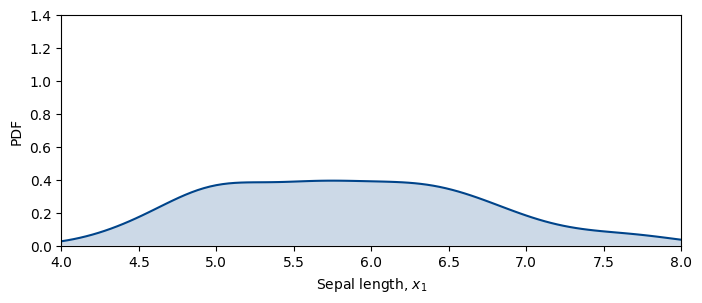

In [22]:
KDE = sm.nonparametric.KDEUnivariate(X1_df)
KDE.fit(bw=0.3)
x1 = np.linspace(4,8,101)
f_x1 = KDE.evaluate(x1)
visualize(x1,f_x1,'#00448A')


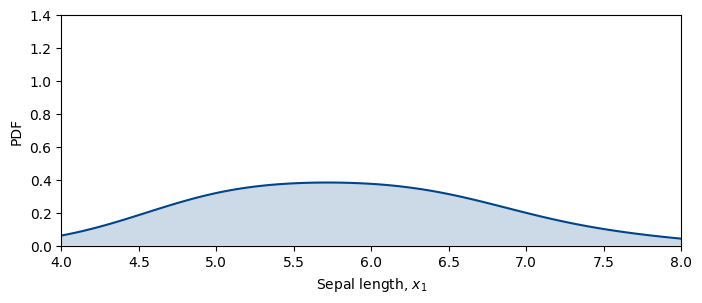

In [24]:
KDE = sm.nonparametric.KDEUnivariate(X1_df)
KDE.fit(bw=0.5)
x1 = np.linspace(4,8,101)
f_x1 = KDE.evaluate(x1)
visualize(x1,f_x1,'#00448A')

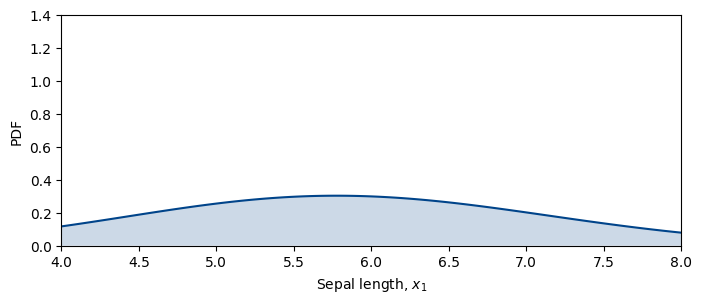

In [25]:
KDE = sm.nonparametric.KDEUnivariate(X1_df)
KDE.fit(bw=1)
x1 = np.linspace(4,8,101)
f_x1 = KDE.evaluate(x1)
visualize(x1,f_x1,'#00448A')

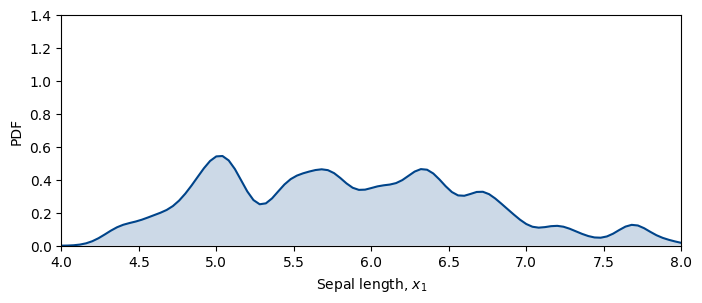

In [27]:
KDE = sm.nonparametric.KDEUnivariate(X1_df)
KDE.fit(bw=0.1)
x1 = np.linspace(4,8,101)
f_x1 = KDE.evaluate(x1)
visualize(x1,f_x1,'#00448A')

###bw也大图像也平滑

# 考虑鸢尾花标签

In [29]:
# 考虑鸢尾花标签，用KDE描述样本数据花萼长度分布
colors = ['#FF3300','#0099FF','#8A8A8A'] # 每个种类的颜色

In [30]:
x1 = np.linspace(4,8,161) # 一系列的点

In [31]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

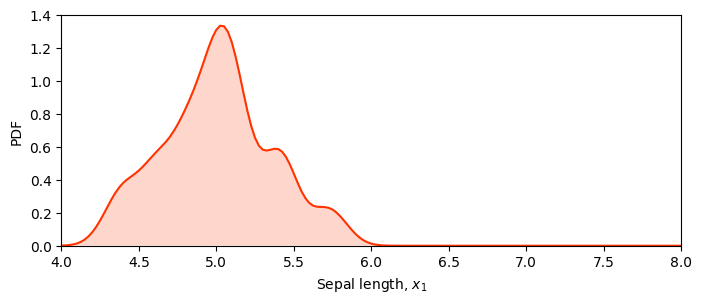

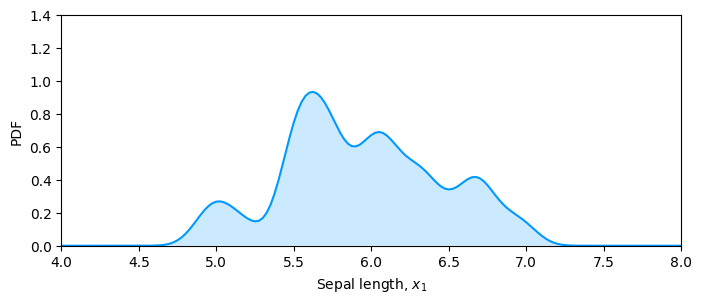

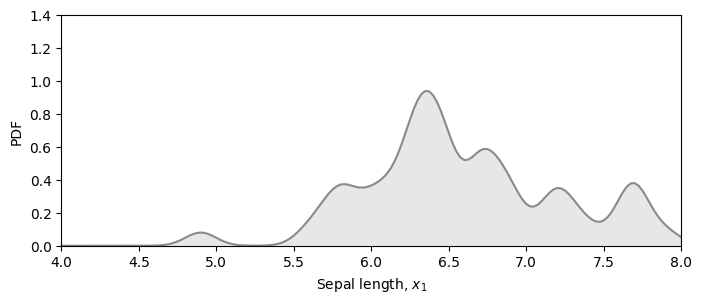

In [32]:
# 遍历每一种类
for idx in range(3):
  # 取出对应的标签数据；iris的target(0 1 2)
  # X1_df[y==idx]:布尔
    KDE_C_i = sm.nonparametric.KDEUnivariate(X1_df[y==idx])
    KDE_C_i.fit(bw=0.1)
    f_x1_given_C_i = KDE_C_i.evaluate(x1) #利用 evaluate() 计算给定数组核密度估计值，以便后续可视化。

    #可视化（x，y, color）
    visualize(x1,f_x1_given_C_i,colors[idx])